## Importing Dependencies

In [2]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Loading realizations into Dataframe

In [3]:
filename = "../constrainedMilkyWay.hdf5"
output = "Output1"

with h5py.File(filename, "r") as f:
    node_path = f"Outputs/{output}/nodeData"

    data = {}
    for key in f[node_path].keys():
        data[key] = f[node_path][key][:]
    
    out_path = f"Outputs/{output}"
    tree_start = f[f"{out_path}/mergerTreeStartIndex"][:]
    tree_count = f[f"{out_path}/mergerTreeCount"][:]
    tree_index = f[f"{out_path}/mergerTreeIndex"][:]

df = pd.DataFrame(data)

# Add tree IDs

df["tree_id"] = -1
for i, start in enumerate(tree_start):
    count = tree_count[i]
    df.loc[start:start + count - 1, "tree_id"] = tree_index[i]

print(df.head())
print(df.columns)
print(df.shape)
print(df["tree_id"].value_counts())

      basicMass  basicTimeLastIsolated  darkMatterProfileScale  \
0  2.569658e+08              13.800484                0.001218   
1  5.898617e+08              13.691062                0.001321   
2  3.318268e+08              13.665727                0.002365   
3  6.379491e+08              13.561722                0.001537   
4  2.463650e+08              13.519278                0.001544   

   mergerTreeIndex  nodeIndex  nodeIsIsolated  nodeLabelIsLMCSubhalo  \
0               97          2               0                      0   
1               97          4               0                      0   
2               97          6               0                      0   
3               97          8               0                      0   
4               97         10               0                      0   

   nodeLabelLMC  nodeLabelWasLMCSubhalo  nodeSubsamplingWeight  ...  \
0             0                       0                    1.0  ...   
1             0             

## Finding SMC Candidates

In [4]:
min_smc_mass = 5.0e9
max_smc_mass = 8.0e9

smc_candidate_mask = (
    (df["nodeLabelWasLMCSubhalo"] == 1) &
    (df["basicMass"] > min_smc_mass) &
    (df["basicMass"] < max_smc_mass)
)

selected = df[smc_candidate_mask]
selected_ids = selected["tree_id"].tolist()
unique_selected_ids = set(selected_ids)
tree_id_with_multiple_candidates = selected["tree_id"].value_counts()
trees_with_multiple_candidates = tree_id_with_multiple_candidates[tree_id_with_multiple_candidates > 1].index.tolist()
trees_with_single_candidate = tree_id_with_multiple_candidates[tree_id_with_multiple_candidates == 1].index.tolist()

print(selected.columns)
print("Selected tree IDs:", selected_ids)
print("Trees with multiple candidates:", trees_with_multiple_candidates)
print("Trees with single candidate:", trees_with_single_candidate)
print("Number selected:", len(selected))
print("Number of unique tree IDs:", len(unique_selected_ids))
print("Number of trees with multiple candidates:", len(trees_with_multiple_candidates))
print("Number of trees with single candidate:", len(trees_with_single_candidate))


Index(['basicMass', 'basicTimeLastIsolated', 'darkMatterProfileScale',
       'mergerTreeIndex', 'nodeIndex', 'nodeIsIsolated',
       'nodeLabelIsLMCSubhalo', 'nodeLabelLMC', 'nodeLabelWasLMCSubhalo',
       'nodeSubsamplingWeight', 'parentIndex', 'satelliteBoundMass',
       'satelliteIndex', 'satellitePositionX', 'satellitePositionY',
       'satellitePositionZ', 'satelliteTidalHeatingNormalized',
       'satelliteVelocityX', 'satelliteVelocityY', 'satelliteVelocityZ',
       'siblingIndex', 'spinAngularMomentum', 'spinAngularMomentumVectorX',
       'spinAngularMomentumVectorY', 'spinAngularMomentumVectorZ', 'tree_id'],
      dtype='object')
Selected tree IDs: [97, 97, 74, 74, 74, 78, 95, 81, 81, 81, 92, 86, 90, 80, 84, 79, 2, 2, 82, 89, 96, 53, 68, 54, 57, 57, 59, 71, 76, 75, 75, 62, 63, 63, 66, 72, 51, 31, 32, 48, 22, 22, 52, 39, 39, 7, 30, 24, 19, 19, 36, 13, 13, 13, 8, 15, 28, 11, 10, 21, 17, 18, 18, 4, 4, 4]
Trees with multiple candidates: [74, 81, 4, 13, 97, 75, 57, 2, 39, 22

## SMC Candidates of trees with Multiple Candidates

In [5]:
special_smc_candidate_mask = (
    (df["tree_id"].isin(trees_with_multiple_candidates)) &
    (df["nodeLabelWasLMCSubhalo"] == 1) &
    (df["basicMass"] > min_smc_mass) &
    (df["basicMass"] < max_smc_mass)
)

special_candidates = df[special_smc_candidate_mask]
print("Number of special candidates:", len(special_candidates))

Number of special candidates: 30


## SMC Candidates from trees with only one SMC

In [6]:
regular_candidate_mask = (
    (df["tree_id"].isin(trees_with_single_candidate)) &
    (df["nodeLabelWasLMCSubhalo"] == 1) &
    (df["basicMass"] > min_smc_mass) &
    (df["basicMass"] < max_smc_mass)
)

regular_candidates = df[regular_candidate_mask]
print("Number of unique candidates:", len(regular_candidates))


Number of unique candidates: 36


## Histograms of Infall times of Regular Candidates vs Special Candidates

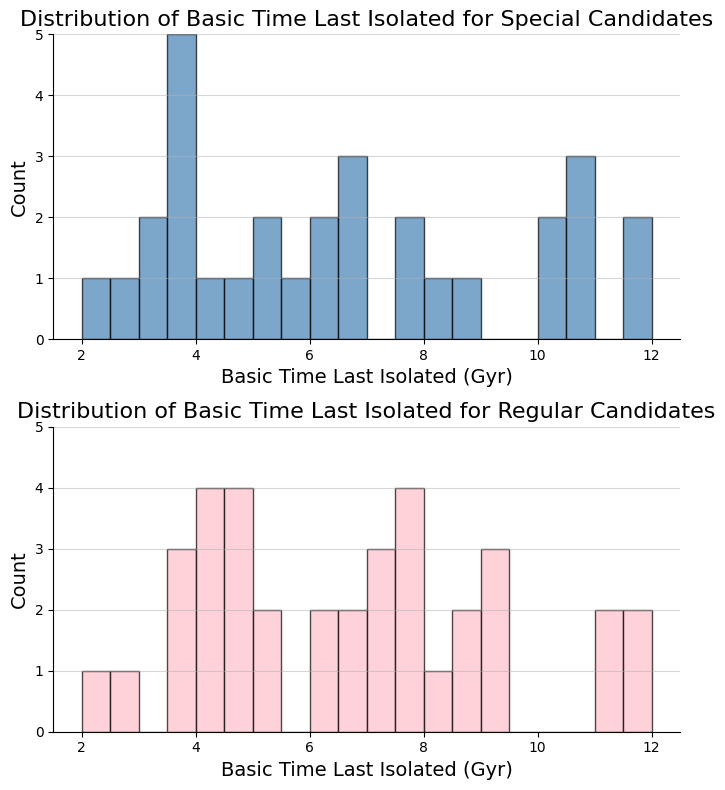

In [7]:
fig, ax = plt.subplots(2, 1, figsize = (7, 8))
bins = np.arange(2, 12.5, 0.5)

ax[0].hist(special_candidates["basicTimeLastIsolated"], bins=bins, color = "steelblue", edgecolor='black', alpha=0.7)
ax[0].set_title("Distribution of Basic Time Last Isolated for Special Candidates", fontsize=16)
ax[0].set_xlabel("Basic Time Last Isolated (Gyr)", fontsize=14)
ax[0].set_ylabel("Count", fontsize=14)
ax[0].set_ymargin(1)
ax[0].set_ylim(0, 5)
ax[0].grid(axis='y', alpha=0.5)

ax[1].hist(regular_candidates["basicTimeLastIsolated"], bins=bins, color = "pink", edgecolor='black', alpha=0.7)
ax[1].set_title("Distribution of Basic Time Last Isolated for Regular Candidates", fontsize=16)
ax[1].set_xlabel("Basic Time Last Isolated (Gyr)", fontsize=14)
ax[1].set_ylabel("Count", fontsize=14)
ax[1].set_ymargin(1)
ax[1].set_ylim(0, 5)
ax[1].grid(axis='y', alpha=0.5)

for axis in ax:
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

